In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
spam_df = pd.read_csv('emails.csv')
spam_df.head(10)

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
5,"Subject: great nnews hello , welcome to medzo...",1
6,Subject: here ' s a hot play in motion homela...,1
7,Subject: save your money buy getting this thin...,1
8,Subject: undeliverable : home based business f...,1
9,Subject: save your money buy getting this thin...,1


In [4]:
spam_df.tail(10)

,text,spam
5718,"Subject: altos na gas model kim , i know you ...",0
5719,Subject: power market research i came across ...,0
5720,Subject: re : visit to houston fyi - - - - -...,0
5721,Subject: ees risk management presentations for...,0
5722,Subject: re : vacation vince : i just found ...,0
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0
5727,Subject: news : aurora 5 . 2 update aurora ve...,0


In [5]:
spam_df.describe()

,spam
count,5728.000000
mean,0.238827
std,0.426404
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [6]:
spam_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [7]:
ham = spam_df[spam_df['spam'] == 0]

In [8]:
ham

,text,spam
1368,"Subject: hello guys , i ' m "" bugging you "" f...",0
1369,Subject: sacramento weather station fyi - - ...,0
1370,Subject: from the enron india newsdesk - jan 1...,0
1371,Subject: re : powerisk 2001 - your invitation ...,0
1372,Subject: re : resco database and customer capt...,0
...,...,...
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0


In [9]:
spam = spam_df[ spam_df['spam'] == 1]
spam

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
...,...,...
1363,Subject: are you ready to get it ? hello ! v...,1
1364,Subject: would you like a $ 250 gas card ? do...,1
1365,"Subject: immediate reply needed dear sir , i...",1
1366,Subject: wanna see me get fisted ? fist bang...,1


In [10]:
print('spam percentage = ', (len(spam) / len(spam_df) * 100, '%'))

spam percentage =  (23.88268156424581, '%')


In [11]:
print('ham percentage = ', (len(ham) / len(spam_df) * 100, '%'))

ham percentage =  (76.11731843575419, '%')


/opt/anaconda3/envs/my/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='spam', ylabel='count'>

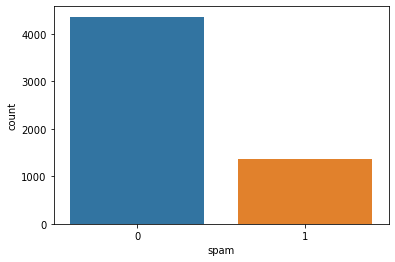

In [12]:
sns.countplot(spam_df['spam'], label='Count spam vs ham')

In [13]:
## count vectorizer example
from sklearn.feature_extraction.text import CountVectorizer

sample_data = ['This is the first document', 'This document is the second document', 'And this is the third document', 'Is this a document?']

sample_vectorizer = CountVectorizer()

In [14]:
X = sample_vectorizer.fit_transform(sample_data)

In [16]:
print(X.toarray())

[[0 1 1 1 0 1 0 1]
 [0 2 0 1 1 1 0 1]
 [1 1 0 1 0 1 1 1]
 [0 1 0 1 0 0 0 1]]


In [17]:
print(sample_vectorizer.get_feature_names())

['and', 'document', 'first', 'is', 'second', 'the', 'third', 'this']


In [20]:
## let's apply it to our example
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
spamham_countvectorizer = vectorizer.fit_transform(spam_df['text'])

In [22]:
print(spamham_countvectorizer.toarray())

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [4 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [23]:
spamham_countvectorizer.shape

(5728, 37303)

In [26]:
label = spam_df['spam'].values
label

array([1, 1, 1, ..., 0, 0, 0])

In [27]:
## train the model

from sklearn.naive_bayes import MultinomialNB

NB_classifier = MultinomialNB()
NB_classifier.fit(spamham_countvectorizer, label)

MultinomialNB()

In [28]:
testing_sample = ['Free money!', 'Hi Marcel let me know if you need more information']

In [29]:
testing_sample_vectorizer = vectorizer.transform(testing_sample) 

In [31]:
test_predict = NB_classifier.predict(testing_sample_vectorizer)
test_predict

array([1, 0])

In [32]:
texts = [
    "CONGRATULATIONS!!! You've been selected to WIN a $500 gift card! Click here NOW to claim your prize!",
    "URGENT: Your account has been suspended! Verify your information immediately at our special link!",
    "Hey, just checking in — are we still on for tomorrow's meeting?"
]

In [33]:
texts_vectorize = vectorizer.transform(texts)

In [34]:
texts_predict = NB_classifier.predict(texts_vectorize)
texts_predict

array([1, 1, 0])

In [35]:
## divide the data into train and test
from sklearn.model_selection import train_test_split
X = spamham_countvectorizer
y = label

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [36]:
from sklearn.naive_bayes import MultinomialNB
NB_classifier = MultinomialNB()

NB_classifier.fit(X_train, y_train)

MultinomialNB()

In [37]:
from sklearn.metrics import classification_report, confusion_matrix

In [38]:
y_predict_train = NB_classifier.predict(X_train)

<AxesSubplot:>

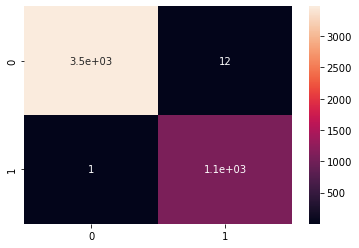

In [39]:
cm = confusion_matrix(y_train, y_predict_train)
sns.heatmap(cm, annot=True)

<AxesSubplot:>

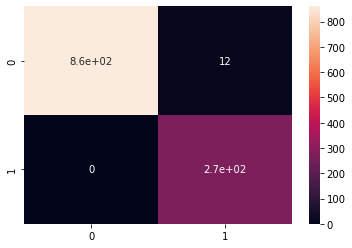

In [40]:
y_predict_test = NB_classifier.predict(X_test)
cm = confusion_matrix(y_test, y_predict_test)
sns.heatmap(cm, annot=True)

In [41]:
print(classification_report(y_test, y_predict_test))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       872
           1       0.96      1.00      0.98       274

    accuracy                           0.99      1146
   macro avg       0.98      0.99      0.99      1146
weighted avg       0.99      0.99      0.99      1146

